In [2]:
!pip install yfinance

In [4]:
import yfinance as yf
import pandas as pd

In [5]:
df = yf.download("AAPL", start="2020-01-01", end="2025-01-01")

/tmp/ipykernel_3347/3487280368.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download("AAPL", start="2020-01-01", end="2025-01-01")
[*********************100%***********************]  1 of 1 completed


In [6]:
df.head()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2020-01-02,72.333878,72.394086,71.091184,71.344054,135480400
2020-01-03,71.630638,72.389257,71.406666,71.563205,146322800
2020-01-06,72.201393,72.239927,70.503531,70.753999,118387200
2020-01-07,71.861824,72.466307,71.642666,72.211026,108872000
2020-01-08,73.017838,73.318877,71.565621,71.565621,132079200


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1258 entries, 2020-01-02 to 2024-12-31
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (Close, AAPL)   1258 non-null   float64
 1   (High, AAPL)    1258 non-null   float64
 2   (Low, AAPL)     1258 non-null   float64
 3   (Open, AAPL)    1258 non-null   float64
 4   (Volume, AAPL)  1258 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 59.0 KB


In [8]:
df.isnull().sum()

,,0
Price,Ticker,
Close,AAPL,0
High,AAPL,0
Low,AAPL,0
Open,AAPL,0
Volume,AAPL,0


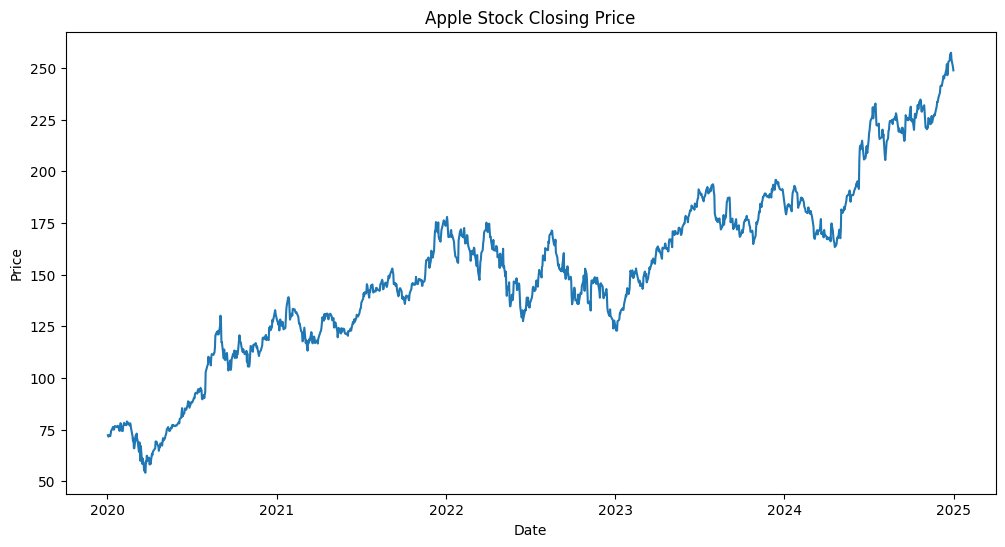

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(df['Close'])
plt.title('Apple Stock Closing Price')
plt.xlabel('Date')
plt.ylabel('Price')
plt.show()

In [10]:
df.describe()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
count,1258.000000,1258.000000,1258.000000,1258.000000,1.258000e+03
mean,151.377786,152.899566,149.680872,151.223470,9.057103e+07
std,41.851998,41.992362,41.629302,41.795804,5.324438e+07
min,54.163689,55.160686,51.324786,55.059297,2.323470e+07
25%,126.279119,127.397081,124.278528,125.724401,5.546825e+07
50%,149.968628,151.709757,148.037171,149.788890,7.628335e+07
75%,175.902031,177.452437,174.337245,175.708231,1.077425e+08
max,257.375580,258.448740,255.994420,256.550862,4.265100e+08


In [11]:
X = df[['Open', 'High', 'Low', 'Volume']]
y = df['Close']

In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [17]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

In [18]:
rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


RandomForestRegressor(random_state=42)

In [19]:
y_pred_rf = rf.predict(X_test)

In [20]:
mae_rf = mean_absolute_error(y_test, y_pred_rf)

rmse_rf = np.sqrt(
    mean_squared_error(y_test, y_pred_rf)
)

r2_rf = r2_score(y_test, y_pred_rf)

print("MAE:", mae_rf)
print("RMSE:", rmse_rf)
print("R² Score:", r2_rf)

MAE: 1.0062503059326657
RMSE: 1.3861897549677114
R² Score: 0.9988897305852344


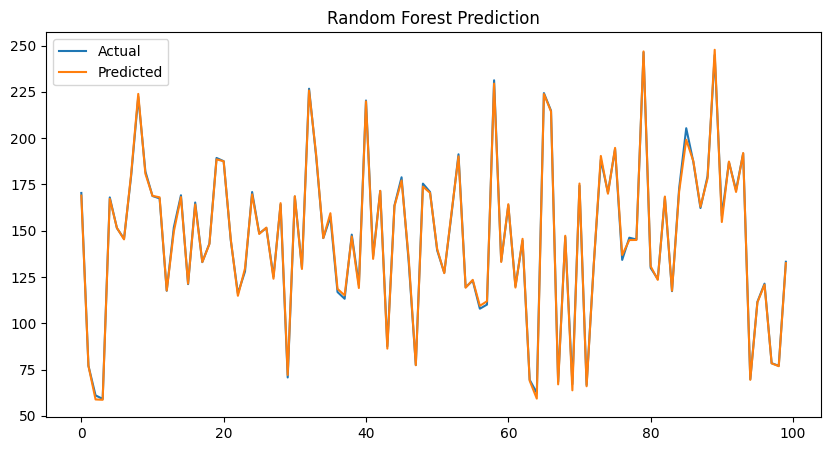

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(
    y_test.values[:100],
    label='Actual'
)

plt.plot(
    y_pred_rf[:100],
    label='Predicted'
)

plt.legend()
plt.title("Random Forest Prediction")
plt.show()

In [14]:
y_pred = model.predict(X_test)

In [15]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R² Score:", r2)

MAE: 0.7418783265331775
RMSE: 0.9982197036916791
R² Score: 0.999424248228509


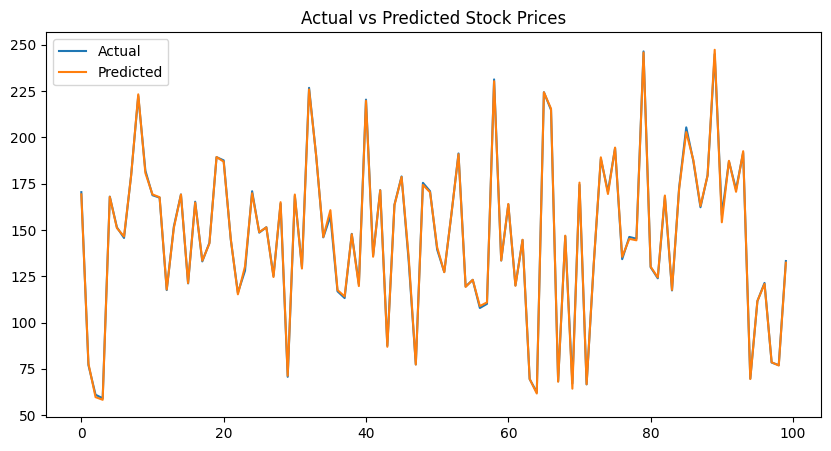

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(y_test.values[:100], label='Actual')
plt.plot(y_pred[:100], label='Predicted')
plt.legend()
plt.title('Actual vs Predicted Stock Prices')
plt.show()

In [22]:
df['Tomorrow_Close'] = df['Close'].shift(-1)

In [23]:
df = df.dropna()

In [24]:
X = df[['Open', 'High', 'Low', 'Close', 'Volume']]

In [25]:
y = df['Tomorrow_Close']

In [26]:
df[['Close','Tomorrow_Close']].head()

Price,Close,Tomorrow_Close
Ticker,AAPL,
Date,,
2020-01-02,72.333878,71.630638
2020-01-03,71.630638,72.201393
2020-01-06,72.201393,71.861824
2020-01-07,71.861824,73.017838
2020-01-08,73.017838,74.568794


In [27]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [28]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [29]:
y_pred = model.predict(X_test)

In [30]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R² Score:", r2)

MAE: 2.0027008781642905
RMSE: 2.750420304154972
R² Score: 0.9956803310945025


In [31]:
X.corr()

,Price,Open,High,Low,Close,Volume
,Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Price,Ticker,,,,,
Open,AAPL,1.000000,0.999398,0.999399,0.998656,-0.637696
High,AAPL,0.999398,1.000000,0.999256,0.999396,-0.629716
Low,AAPL,0.999399,0.999256,1.000000,0.999392,-0.645904
Close,AAPL,0.998656,0.999396,0.999392,1.000000,-0.638079
Volume,AAPL,-0.637696,-0.629716,-0.645904,-0.638079,1.000000
